Final Project Movie Recommender

Idea for project to create a simple ML to recommend Movies. 

In [3]:
# Any setup that may be needed for the tests can be done here
!pip install numpy pandas scikit-learn matplotlib seaborn openpyxl kagglehub ipywidgets jupyterlab notebook


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


EDA process

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
import pandas as pd
import os

# 1. Define the folder path
folder_path = r"C:\Users\lulul\OneDrive\Documents\Final Project\MovieData"  # Update this to your actual folder path

# 2. List the files to make sure we have the right CSV name
# This helps if the file is named 'movies.csv' instead of 'MovieData.csv'
print("Files found:", os.listdir(folder_path))

# 3. Join the path with your actual filename
# REPLACE 'movies_metadata.csv' with the actual name you see in the list above
file_name = "movies_metadata.csv" 
full_path = os.path.join(folder_path, file_name)

# 4. Load to review the data
df = pd.read_csv(full_path)
print("--- First 5 Rows ---")
print(df.head())
print("--- Last 5 Rows ---")
print(df.tail())

Files found: ['credits.csv', 'keywords.csv', 'links.csv', 'links_small.csv', 'movies_metadata.csv', 'ratings.csv', 'ratings_small.csv']
--- First 5 Rows ---
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_

C:\Users\lulul\AppData\Local\Temp\ipykernel_13380\2891368086.py:17: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)


In [6]:
# 1. Define the folder path
folder_rating = r"C:\Users\lulul\OneDrive\Documents\Final Project\MovieData"  # Update this to your actual folder path

# 2. List the files to make sure we have the right CSV name
# This helps if the file is named 'movies.csv' instead of 'MovieData.csv'
print("Files found:", os.listdir(folder_rating))

# 3. Join the path with your actual filename
# REPLACE 'movies_metadata.csv' with the actual name you see in the list above
file_rating = "ratings.csv" 
full_rating = os.path.join(folder_rating, file_rating)

# 4. Load to review the data
df = pd.read_csv(full_rating)
print("--- First 5 Rows ---")
print(df.head())
print("--- Last 5 Rows ---")
print(df.tail())

Files found: ['credits.csv', 'keywords.csv', 'links.csv', 'links_small.csv', 'movies_metadata.csv', 'ratings.csv', 'ratings_small.csv']
--- First 5 Rows ---
   userId  movieId  rating   timestamp
0       1      110     1.0  1425941529
1       1      147     4.5  1425942435
2       1      858     5.0  1425941523
3       1     1221     5.0  1425941546
4       1     1246     5.0  1425941556
--- Last 5 Rows ---
          userId  movieId  rating   timestamp
26024284  270896    58559     5.0  1257031564
26024285  270896    60069     5.0  1257032032
26024286  270896    63082     4.5  1257031764
26024287  270896    64957     4.5  1257033990
26024288  270896    71878     2.0  1257031858


In [7]:
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())
print("--- Dataset Shape ---")
print(df.shape)
print("--- Dataset Info ---")
print(df.info)

--- Missing Values Before Cleaning ---
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
--- Dataset Shape ---
(26024289, 4)
--- Dataset Info ---
<bound method DataFrame.info of           userId  movieId  rating   timestamp
0              1      110     1.0  1425941529
1              1      147     4.5  1425942435
2              1      858     5.0  1425941523
3              1     1221     5.0  1425941546
4              1     1246     5.0  1425941556
...          ...      ...     ...         ...
26024284  270896    58559     5.0  1257031564
26024285  270896    60069     5.0  1257032032
26024286  270896    63082     4.5  1257031764
26024287  270896    64957     4.5  1257033990
26024288  270896    71878     2.0  1257031858

[26024289 rows x 4 columns]>


In [8]:
# 1. Define the folder path
folder_keywords = r"C:\Users\lulul\OneDrive\Documents\Final Project\MovieData"  # Update this to your actual folder path

# 2. List the files to make sure we have the right CSV name
# This helps if the file is named 'movies.csv' instead of 'MovieData.csv'
print("Files found:", os.listdir(folder_keywords))

# 3. Join the path with your actual filename
# REPLACE 'movies_metadata.csv' with the actual name you see in the list above
file_keywords = "keywords.csv" 
full_keywords = os.path.join(folder_keywords, file_keywords)

# 4. Load to review the data
df = pd.read_csv(full_keywords)
print("--- First 5 Rows ---")
print(df.head())
print("--- Last 5 Rows ---")
print(df.tail())

Files found: ['credits.csv', 'keywords.csv', 'links.csv', 'links_small.csv', 'movies_metadata.csv', 'ratings.csv', 'ratings_small.csv']
--- First 5 Rows ---
      id                                           keywords
0    862  [{'id': 931, 'name': 'jealousy'}, {'id': 4290,...
1   8844  [{'id': 10090, 'name': 'board game'}, {'id': 1...
2  15602  [{'id': 1495, 'name': 'fishing'}, {'id': 12392...
3  31357  [{'id': 818, 'name': 'based on novel'}, {'id':...
4  11862  [{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n...
--- Last 5 Rows ---
           id                                           keywords
46414  439050             [{'id': 10703, 'name': 'tragic love'}]
46415  111109  [{'id': 2679, 'name': 'artist'}, {'id': 14531,...
46416   67758                                                 []
46417  227506                                                 []
46418  461257                                                 []


In [9]:
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())
print("--- Dataset Shape ---")
print(df.shape)
print("--- Dataset Info ---")
print(df.info)

--- Missing Values Before Cleaning ---
id          0
keywords    0
dtype: int64
--- Dataset Shape ---
(46419, 2)
--- Dataset Info ---
<bound method DataFrame.info of            id                                           keywords
0         862  [{'id': 931, 'name': 'jealousy'}, {'id': 4290,...
1        8844  [{'id': 10090, 'name': 'board game'}, {'id': 1...
2       15602  [{'id': 1495, 'name': 'fishing'}, {'id': 12392...
3       31357  [{'id': 818, 'name': 'based on novel'}, {'id':...
4       11862  [{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n...
...       ...                                                ...
46414  439050             [{'id': 10703, 'name': 'tragic love'}]
46415  111109  [{'id': 2679, 'name': 'artist'}, {'id': 14531,...
46416   67758                                                 []
46417  227506                                                 []
46418  461257                                                 []

[46419 rows x 2 columns]>


In [10]:
# 1. Define the folder path
folder_credits = r"C:\Users\lulul\OneDrive\Documents\Final Project\MovieData"  # Update this to your actual folder path

# 2. List the files to make sure we have the right CSV name
# This helps if the file is named 'movies.csv' instead of 'MovieData.csv'
print("Files found:", os.listdir(folder_credits))

# 3. Join the path with your actual filename
# REPLACE 'movies_metadata.csv' with the actual name you see in the list above
file_credits = "credits.csv" 
full_credits = os.path.join(folder_credits, file_credits)

# 4. Load to review the data
df = pd.read_csv(full_credits)
print("--- First 5 Rows ---")
print(df.head())
print("--- Last 5 Rows ---")
print(df.tail())


Files found: ['credits.csv', 'keywords.csv', 'links.csv', 'links_small.csv', 'movies_metadata.csv', 'ratings.csv', 'ratings_small.csv']
--- First 5 Rows ---
                                                cast  \
0  [{'cast_id': 14, 'character': 'Woody (voice)',...   
1  [{'cast_id': 1, 'character': 'Alan Parrish', '...   
2  [{'cast_id': 2, 'character': 'Max Goldman', 'c...   
3  [{'cast_id': 1, 'character': "Savannah 'Vannah...   
4  [{'cast_id': 1, 'character': 'George Banks', '...   

                                                crew     id  
0  [{'credit_id': '52fe4284c3a36847f8024f49', 'de...    862  
1  [{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...   8844  
2  [{'credit_id': '52fe466a9251416c75077a89', 'de...  15602  
3  [{'credit_id': '52fe44779251416c91011acb', 'de...  31357  
4  [{'credit_id': '52fe44959251416c75039ed7', 'de...  11862  
--- Last 5 Rows ---
                                                    cast  \
45471  [{'cast_id': 0, 'character': '', 'credit_id': .

In [11]:
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())
print("--- Dataset Shape ---")
print(df.shape)
print("--- Dataset Info ---")
print(df.info)

--- Missing Values Before Cleaning ---
cast    0
crew    0
id      0
dtype: int64
--- Dataset Shape ---
(45476, 3)
--- Dataset Info ---
<bound method DataFrame.info of                                                     cast  \
0      [{'cast_id': 14, 'character': 'Woody (voice)',...   
1      [{'cast_id': 1, 'character': 'Alan Parrish', '...   
2      [{'cast_id': 2, 'character': 'Max Goldman', 'c...   
3      [{'cast_id': 1, 'character': "Savannah 'Vannah...   
4      [{'cast_id': 1, 'character': 'George Banks', '...   
...                                                  ...   
45471  [{'cast_id': 0, 'character': '', 'credit_id': ...   
45472  [{'cast_id': 1002, 'character': 'Sister Angela...   
45473  [{'cast_id': 6, 'character': 'Emily Shaw', 'cr...   
45474  [{'cast_id': 2, 'character': '', 'credit_id': ...   
45475                                                 []   

                                                    crew      id  
0      [{'credit_id': '52fe4284c3a36847f8024

Adjusting Data to add in random forest

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Define your paths
folder_path = r"C:\Users\lulul\OneDrive\Documents\Final Project\MovieData"

# Load the two specific files
movies_df = pd.read_csv(os.path.join(folder_path, "movies_metadata.csv"), low_memory=False)
ratings_df = pd.read_csv(os.path.join(folder_path, "ratings_small.csv"))

# Ensure the ID columns are the same type (strings or ints) before merging
movies_df['id'] = pd.to_numeric(movies_df['id'], errors='coerce')
ratings_df['movieId'] = pd.to_numeric(ratings_df['movieId'], errors='coerce')

# Merge the datasets on the ID column
# We use an 'inner' join to only keep movies that have ratings
combined_df = pd.merge(ratings_df, movies_df, left_on='movieId', right_on='id', how='inner')

print(f"Combined Data Shape: {combined_df.shape}")

Combined Data Shape: (44994, 28)


Feature testing

In [13]:
# Use only 20% of the total merged data
df_subset = combined_df.sample(frac=0.2, random_state=42)

# Preprocessing: Select numeric features and drop rows with missing values
# Example: Using 'vote_average' and 'popularity' to predict a high rating (binary classification)
X = df_subset[['vote_average', 'popularity']].fillna(0)
y = (df_subset['rating'] >= 4).astype(int) # 1 if rating is high, 0 otherwise

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Training ML based on those set features the vote average, poplularity and using rating.

In [14]:
# 1. Create and train the Random Forest
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

# 2. Make predictions
y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy on the {len(df_subset)} row subset: {accuracy_rf:.2%}")

Accuracy on the 8999 row subset: 60.78%


Pullling other feature columns in list to encode

In [15]:
import ast

# Convert string representation of list to actual list
def extract_names(column_data):
    try:
        # ast.literal_eval safely evaluates a string as a Python object
        return [item['name'] for item in ast.literal_eval(column_data)]
    except:
        return []

df_subset['genres_list'] = df_subset['genres'].apply(extract_names)
df_subset['languages_list'] = df_subset['spoken_languages'].apply(extract_names)

Encoding

In [16]:
from sklearn.preprocessing import MultiLabelBinarizer

# Initialize the binarizer for genres
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df_subset['genres_list'])
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_, index=df_subset.index)

# Join the new genre columns back to your main numeric features
X = pd.concat([X, genre_df], axis=1)

adding in the new features genre and original language

In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Prepare numeric features first
X_numeric = df_subset[['budget', 'popularity']].fillna(0)

# 2. Add encoded Genres
mlb_gen = MultiLabelBinarizer()
genre_data = mlb_gen.fit_transform(df_subset['genres_list'])
X_genres = pd.DataFrame(genre_data, columns=mlb_gen.classes_, index=df_subset.index)

# 3. Combine them
X = pd.concat([X_numeric, X_genres], axis=1)

# Ensure y is binary for the Classifier (e.g., "Is it a 4-star movie?")
y = (df_subset['rating'] >= 4).astype(int)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print(f"Model Accuracy with Genres: {rf.score(X_test, y_test):.2%}")

Model Accuracy with Genres: 60.72%


Plotting feature importance

C:\Users\lulul\AppData\Local\Temp\ipykernel_13380\3311724314.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:15]], y=feature_names[indices[:15]], palette="viridis")


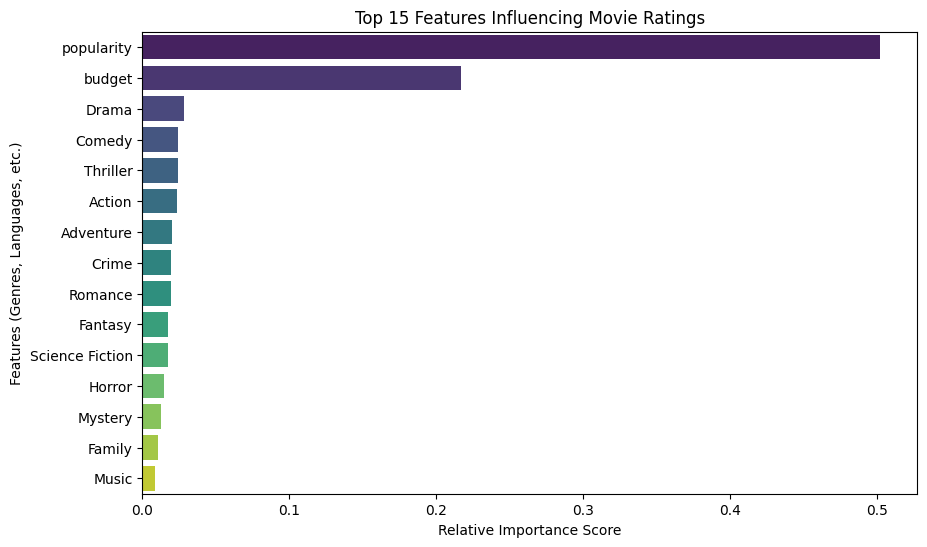

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Get the importance values from the model
importances = rf.feature_importances_
feature_names = X.columns

# 2. Sort them in descending order
indices = np.argsort(importances)[::-1]

# 3. Plot the top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices[:15]], y=feature_names[indices[:15]], palette="viridis")

plt.title("Top 15 Features Influencing Movie Ratings")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features (Genres, Languages, etc.)")
plt.show()

Viewing the results

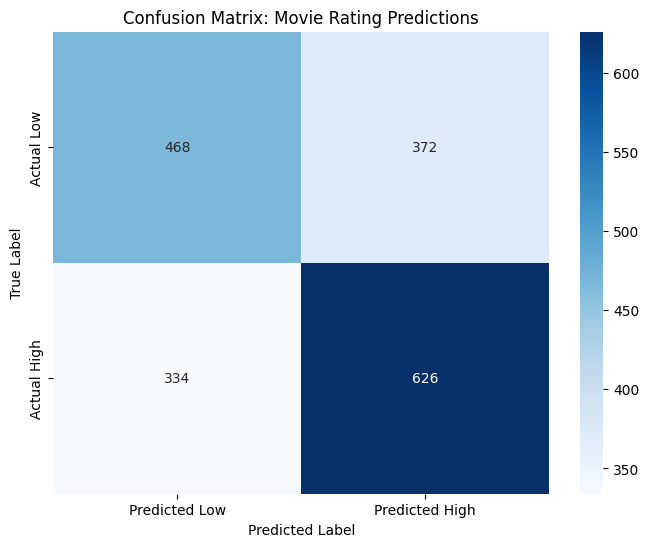

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate the confusion matrix data
# y_test are the real values, y_pred_rf are your model's guesses
cm = confusion_matrix(y_test, y_pred_rf)

# 2. Plotting using Seaborn for a cleaner look
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])

plt.title('Confusion Matrix: Movie Rating Predictions')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Model is showing highly dependant on popularity and budget to rate it higher. 

In [20]:
from sklearn.metrics import classification_report

print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Low Rating', 'High Rating']))

--- Detailed Classification Report ---
              precision    recall  f1-score   support

  Low Rating       0.58      0.56      0.57       840
 High Rating       0.63      0.65      0.64       960

    accuracy                           0.61      1800
   macro avg       0.61      0.60      0.60      1800
weighted avg       0.61      0.61      0.61      1800



Weight of popluarity and budget skrews how a user will rate. Will test another model using K-means 

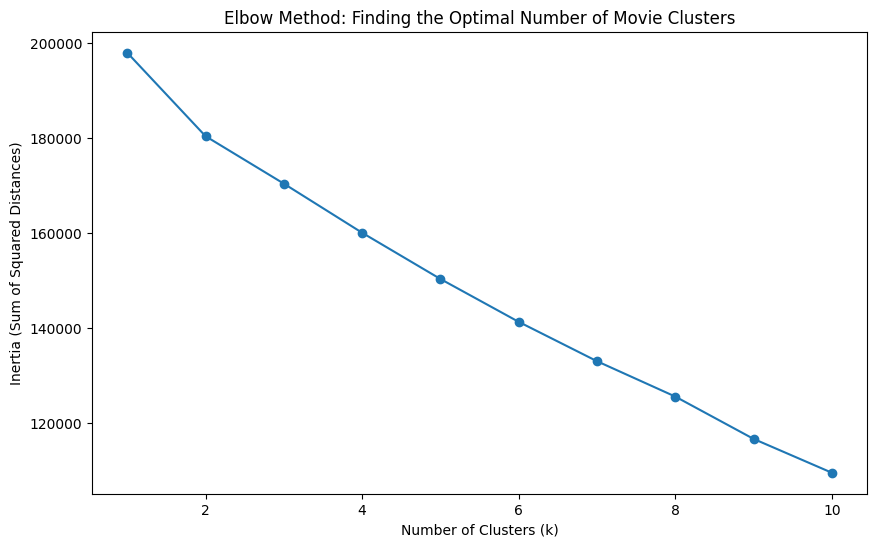

In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Standardize your features (Crucial for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Use the X you built with numeric + encoded genres

# 2. Run the Elbow Method (Your code)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 3. Plot the Elbow
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method: Finding the Optimal Number of Movie Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.show()

The K elbow is harder to find here since the it is a gradual change. Moving to PCA to get more to help narrow down.

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Scale your features (Mandatory for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X contains numeric + encoded genres/languages

# 2. Reduce dimensions with PCA
# We'll reduce it to 2 components so we can plot it on a 2D graph
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Check how much information we kept
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# 3. Run K-Means on the PCA results instead of the raw data
# This usually results in much cleaner 'groups'
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

Total variance explained: 20.93%


Groups have been clean up. Now rerunning clusters with updated groupings.

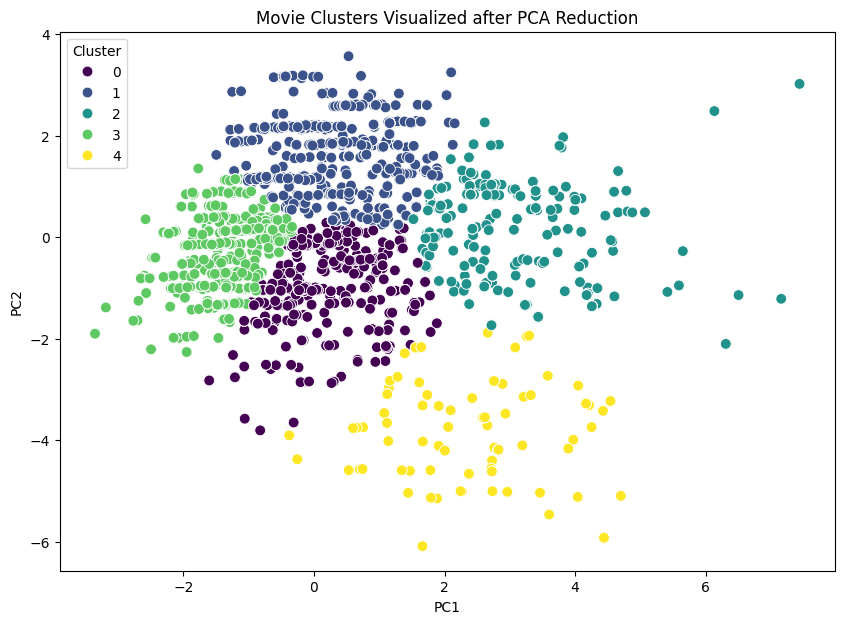

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting
plot_df = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
plot_df["Cluster"] = clusters

# Visualize the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=plot_df, palette='viridis', s=60)
plt.title('Movie Clusters Visualized after PCA Reduction')
plt.show()

In this model the 4 yellow plots looks the most distinct. Will add back in labels to review.

In [24]:
from sklearn.cluster import KMeans

# 1. Fit KMeans using the k=4 you identified from the PCA plot
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

# 2. Add these labels back to your original DataFrame
df_subset['cluster_label'] = cluster_labels

# 3. View the movies in each cluster
for i in range(4):
    print(f"\n--- Movies in Cluster {i} ---")
    # Show the first 10 movie titles in this specific cluster
    print(df_subset[df_subset['cluster_label'] == i]['original_title'].head(10))


--- Movies in Cluster 0 ---
36148                                   Friends with Money
38617                            Die Mörder sind unter uns
25415                                         Belle Époque
43679                                   A Hard Day's Night
2055                 Nosferatu, eine Symphonie des Grauens
30623                                       License to Wed
34038           Air: Eating, Sleeping, Waiting and Playing
27040    Shriek If You Know What I Did Last Friday the ...
38667                                     Meet the Parents
1232                            La passion de Jeanne d'Arc
Name: original_title, dtype: str

--- Movies in Cluster 1 ---
32469                                          Titanic
31916    In the Name of the King: A Dungeon Siege Tale
26304                                        Star Wars
5181                                    Batman Returns
29151                          Lara Croft: Tomb Raider
43496               Terminator 3: Rise of th

Previous infomation shows hows the prior K grouped movies with cluster 0 showing more foreign movies and cluster 1 showing more epics.

In [26]:
# 1. Convert columns to numeric, forcing errors to NaN
df_subset['budget'] = pd.to_numeric(df_subset['budget'], errors='coerce')
df_subset['popularity'] = pd.to_numeric(df_subset['popularity'], errors='coerce')
df_subset['rating'] = pd.to_numeric(df_subset['rating'], errors='coerce')

# 2. Now run the profile again (adding numeric_only=True for safety)
cluster_profile = df_subset.groupby('cluster_label')[['budget', 'popularity', 'rating']].mean(numeric_only=True)

print("--- Cluster Profiles ---")
print(cluster_profile)

--- Cluster Profiles ---
                     budget  popularity    rating
cluster_label                                    
0              7.932581e+06    6.418519  3.533026
1              6.753255e+07   13.260133  3.475751
2              1.493019e+07    8.316844  3.659063
3              4.114610e+07   10.884166  3.610442


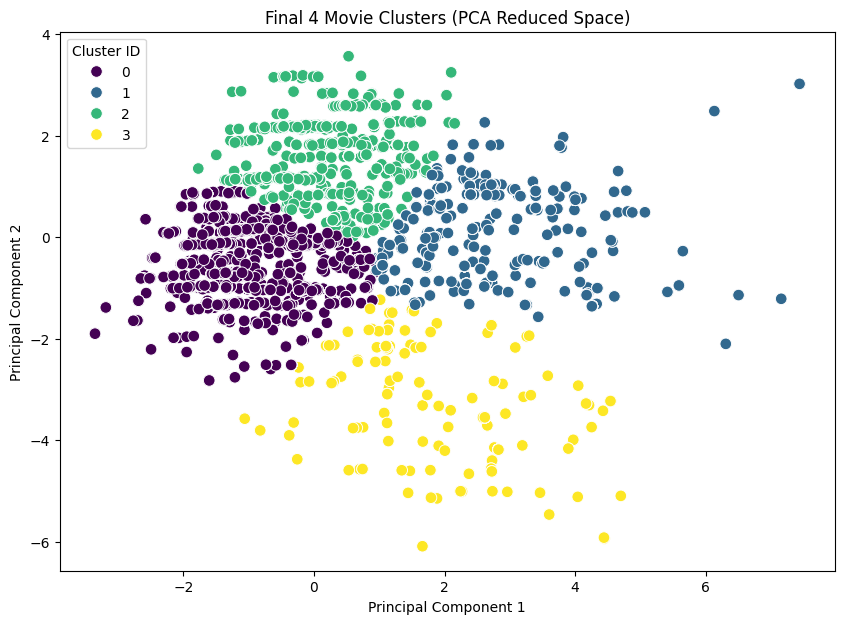

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', s=70)
plt.title('Final 4 Movie Clusters (PCA Reduced Space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster ID')
plt.show()

Retesting using 3 most distinct clusters.

In [29]:
# 1. Fit KMeans with your most distinct k (3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
final_clusters = kmeans.fit_predict(X_pca)

# 2. Add them to your dataframe
df_subset['final_cluster'] = final_clusters

Testing the results.

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

# Create a binary target based on ratings (High = 1, Low = 0)
df_subset['is_high_rating'] = (df_subset['rating'] >= 4).astype(int)

# To test "Accuracy", we see if one specific cluster is a good predictor of high ratings
# Let's say Cluster 1 looks like the 'High Rated' group in your plots:
y_true = df_subset['is_high_rating']
y_pred_cluster = (df_subset['final_cluster'] == 1).astype(int) 

# 3. Print the metrics
print("--- Evaluation of Cluster 1 as a 'High Rating' Predictor ---")
print(classification_report(y_true, y_pred_cluster))

--- Evaluation of Cluster 1 as a 'High Rating' Predictor ---
              precision    recall  f1-score   support

           0       0.46      0.44      0.45      4290
           1       0.51      0.53      0.52      4709

    accuracy                           0.49      8999
   macro avg       0.49      0.49      0.49      8999
weighted avg       0.49      0.49      0.49      8999



Visually seeing how the groups adjust.

--- Cluster vs. Actual Rating Count ---
is_high_rating     0     1
final_cluster             
0               1133  1397
1               2397  2505
2                760   807


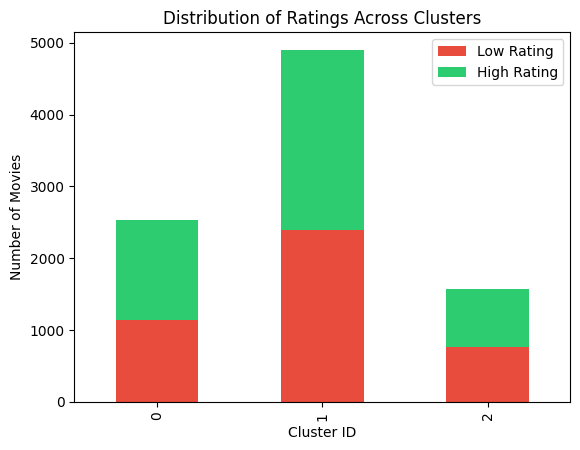

In [31]:
# Create a cross-tab table
ct = pd.crosstab(df_subset['final_cluster'], df_subset['is_high_rating'])
print("--- Cluster vs. Actual Rating Count ---")
print(ct)

# Plot it
ct.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'])
plt.title('Distribution of Ratings Across Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Movies')
plt.legend(['Low Rating', 'High Rating'])
plt.show()

Based in finding still hard to tell since data is still not really dividing based on the ratings or quality. Model still needs more tuning.